In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [6]:
(X_train,y_train), (X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 22s 2us/step


0


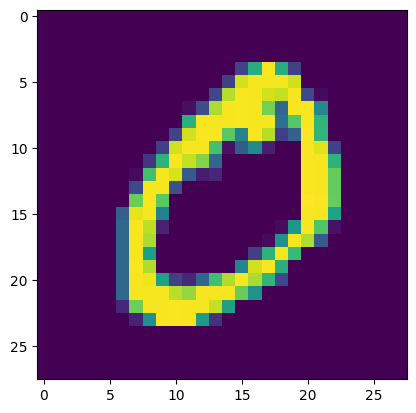

In [14]:
print(y_train[1])
plt.imshow(X_train[1])
plt.show()

# Applying ANN

In [15]:
model = Sequential()

In [17]:
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\DataScience\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
X_train= X_train/255
X_test = X_test/255

In [24]:
history = model.fit(X_train,y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9487 - loss: 0.1487 - val_accuracy: 0.9758 - val_loss: 0.0870
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9958 - loss: 0.0149 - val_accuracy: 0.9769 - val_loss: 0.0961
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9770 - val_loss: 0.1059
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9957 - loss: 0.0134 - val_accuracy: 0.9746 - val_loss: 0.1305
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9957 - loss: 0.0125 - val_accuracy: 0.9746 - val_loss: 0.1188
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9741 - val_loss: 0.1319
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.9772 - val_loss: 0.1210
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9964 - loss: 0.0121 - 

In [25]:
# this look like overfitting because loss is decrease but val_loss increase

In [30]:
# prediction
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [32]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.978

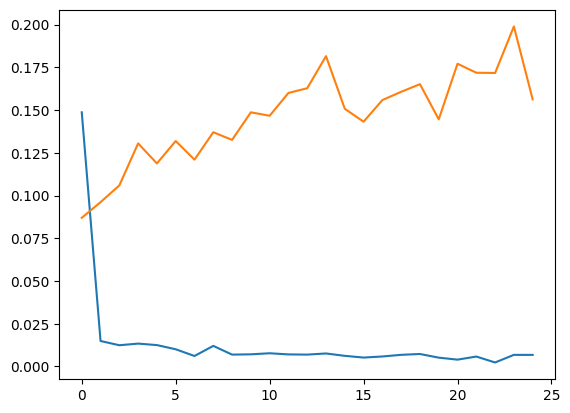

In [34]:
# plotting the loss & val_loss 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

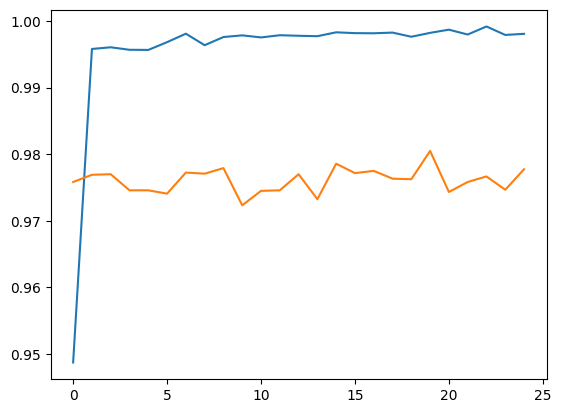

In [35]:
# plotting accuracy score
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

# Graph ko dekh kr hi lg rha hai ye over fitting ho gya hai (esko sahi karne ke liye hyperparameter tune karna parega)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
predicted value by model:  [0]
actual Value 👇


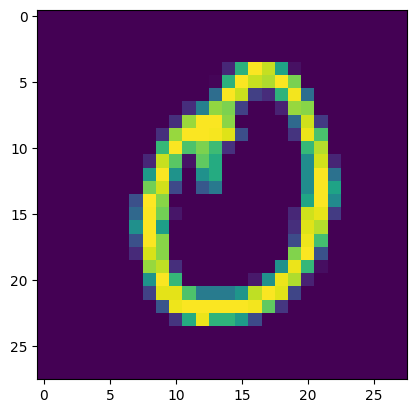

In [43]:
# look the model prediction

print('predicted value by model: ', model.predict(X_train[118].reshape(1,28,28)).argmax(axis=1))
print("actual Value 👇")
plt.imshow(X_train[118])
plt.show()